# Comparación de Gini y entropía

Práctica 4 · ENDIREH 2021

**Estado:** configuración inicial; análisis pendiente.

**Objetivo para la siguiente etapa:** Aplicar Gini y entropía a las frecuencias de una misma variable categórica y comparar sus interpretaciones.

La entrada es el CSV renombrado, generado desde el archivo limpio de la Práctica 3 en `ajuste_columnas_practica_4.ipynb`. Por ahora solo se preparan imports, carga y revisión de columnas.


## 1. Configuración del proyecto

Selecciona el entorno Python `endireh` antes de ejecutar las celdas.


In [1]:
from pathlib import Path
import sys

# Funciona si Jupyter se inicia en la raíz o dentro de notebooks/.
RUTA_PROYECTO = next(
    (ruta for ruta in (Path.cwd(), *Path.cwd().parents)
     if (ruta / "config" / "rutas.py").is_file()),
    None,
)
if RUTA_PROYECTO is None:
    raise FileNotFoundError(
        "No se encontró config/rutas.py. Abre el notebook dentro del proyecto."
    )
if str(RUTA_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RUTA_PROYECTO))


In [2]:
import polars as pl
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from config.rutas import RUTA_ENDIREH_RENOMBRADO_CSV

sns.set_theme(style="whitegrid")


## 2. Carga del dataset procesado

Se conserva el CSV original. La validación de columnas no garantiza que los datos estén listos para todos los cálculos.


In [3]:
if not RUTA_ENDIREH_RENOMBRADO_CSV.is_file():
    raise FileNotFoundError(
        f"No se encontró el CSV procesado: {RUTA_ENDIREH_RENOMBRADO_CSV}. "
        "Ejecuta primero notebooks/ajuste_columnas_practica_4.ipynb."
    )

df = pl.read_csv(RUTA_ENDIREH_RENOMBRADO_CSV)

# Solo se valida la estructura básica; no se limpian ni transforman datos.
columnas_requeridas = {
    "cve_entidad", "nom_entidad", "sufrio_violencia_pareja", "factor_expansion"
}
columnas_faltantes = columnas_requeridas.difference(df.columns)
if columnas_faltantes:
    raise ValueError(f"Faltan columnas requeridas: {sorted(columnas_faltantes)}")

print(f"Archivo: {RUTA_ENDIREH_RENOMBRADO_CSV.name}")
print(f"Filas: {df.height:,} | Columnas: {df.width}")
df.head(5)


Archivo: endireh_2021_renombrado.csv
Filas: 110,127 | Columnas: 24


cve_entidad,nom_entidad,cve_municipio,nom_municipio,anios_sin_convivencia_pareja,tipo_union,tipo_cuestionario,estado_civil_id,estado_civil_desc,estrato_sociodemografico_muestreo,entrevistada_trabaja_id,entrevistada_trabaja_desc,ingreso_laboral_entrevistada,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,hogar_tiene_ahorros_id,hogar_tiene_ahorros_desc,vivienda_propiedad_miembro_hogar_id,vivienda_propiedad_miembro_hogar_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta
i64,str,i64,str,i64,i64,str,i64,str,i64,i64,str,f64,i64,str,i64,str,i64,str,i64,str,i64,i64,i64
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3,"""A1""",5,"""Casada""",4,1,"""Sí""",10000.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3,"""A1""",5,"""Casada""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",1,"""Sí""",1,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",13,3,"""B2""",4,"""Viuda""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",2,"""No""",0,227,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,null,"""C1""",6,"""Soltera""",4,1,"""Sí""",8500.0,1,"""Sí""",2,"""No""",1,"""Sí""",1,"""Sí""",0,113,2021
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",20,3,"""B1""",2,"""Separada""",2,1,"""Sí""",400.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",1,155,2021


## 3. Variables y ponderación

La entropía de Shannon cuantifica la incertidumbre promedio asociada a una variable aleatria, de hecho es muy parecida al concepto de termondinámica. Por otra parte, el coeficiente de Gini, en pocas palabras, cuantifica la desigualdad: mientras es más cercano a 0 hay menos desigualdad, y mientras más cercano a 1 habrá más desigualdad.

En éste caso, vamos a utilizar como referencia el estado civil, el cual tiene 6 posibles respuestas en la encuesta, lo que convierte ésta variable en el candidato perfecto para medir la concentración de una misma variable.

Por la naturaleza de EDIREH, vamos a utilizar el factor de expansión para calcular las frecuencias ponderadas, así, la distribución utilizada en los cálculos va a representar a una población estimada.


In [4]:
frecuencias_estado_civil = (
    df
    .group_by("estado_civil_desc")
    .agg(
        pl.col("factor_expansion")
        .sum()
        .alias("frecuencia_ponderada")
    )
    .sort(
        "frecuencia_ponderada",
        descending=True
    )
)

frecuencias_estado_civil


estado_civil_desc,frecuencia_ponderada
str,i64
"""Casada""",18030938
"""Soltera""",12962434
"""Unión libre""",9483688
"""Viuda""",4393761
"""Separada""",4308682
"""Divorciada""",1343966


## 4. Cálculos

vamos a utilizar las funciones reutilizables de `src/statistics/` para nuestros cálculos:


In [5]:
from src.statistics.concentracion import coeficiente_gini
from src.statistics.heterogeneidad import entropia_shannon

frecuencias = (
    frecuencias_estado_civil["frecuencia_ponderada"]
    .to_numpy()
)

entropia = entropia_shannon(frecuencias)
entropia_maxima = np.log2(6)
entropia_normalizada = entropia / entropia_maxima
gini = coeficiente_gini(frecuencias)
tabla_indices = pl.DataFrame({
    "Medida": [
        "Entropía de Shannon",
        "Entropía máxima",
        "Entropía normalizada",
        "Coeficiente de Gini"
    ],
    "Valor": [
        entropia,
        entropia_maxima,
        entropia_normalizada,
        gini
    ]
}).with_columns(
    pl.col("Valor").round(2)
)

tabla_indices

Medida,Valor
str,f64
"""Entropía de Shannon""",2.24
"""Entropía máxima""",2.58
"""Entropía normalizada""",0.86
"""Coeficiente de Gini""",0.38


## 5. Tablas y visualizaciones

Ahora, vamos a mostrar la distribución ponderada de las 6 variables posibles de `estado_civil_dsc`, tanto en tabla como en gráfica, además, se exhibe de la misma manera la curva de Lorenz, para poder apreciar la desigualdad.


In [6]:
tabla_estado_civil = (
    frecuencias_estado_civil
    .with_columns(
        (
            pl.col("frecuencia_ponderada")
            / pl.col("frecuencia_ponderada").sum()
        ).alias("proporcion")
    )
    .with_columns(
        (pl.col("proporcion") * 100)
        .round(2)
        .alias("porcentaje")
    )
)

tabla_estado_civil

estado_civil_desc,frecuencia_ponderada,proporcion,porcentaje
str,i64,f64,f64
"""Casada""",18030938,0.356882,35.69
"""Soltera""",12962434,0.256563,25.66
"""Unión libre""",9483688,0.187709,18.77
"""Viuda""",4393761,0.086965,8.7
"""Separada""",4308682,0.085281,8.53
"""Divorciada""",1343966,0.026601,2.66


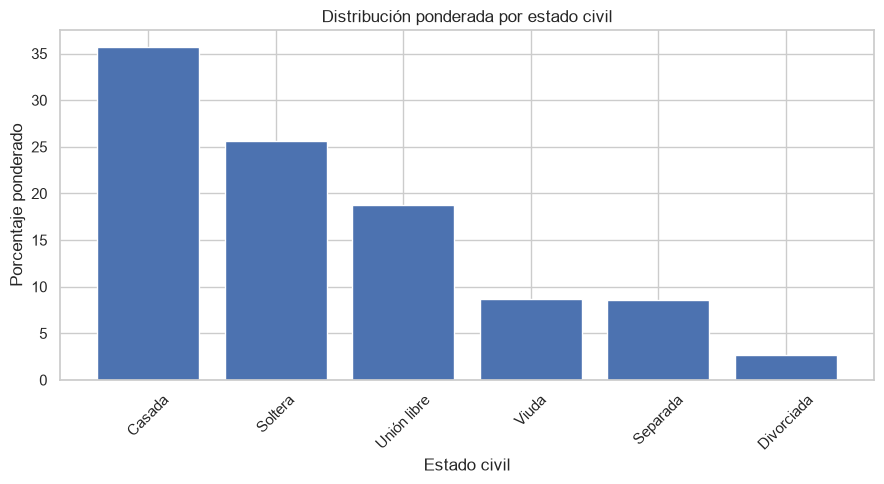

In [7]:
categorias = tabla_estado_civil[
    "estado_civil_desc"
].to_list()

porcentajes = tabla_estado_civil[
    "porcentaje"
].to_list()

plt.figure(figsize=(9, 5))

plt.bar(
    categorias,
    porcentajes
)

plt.xlabel("Estado civil")
plt.ylabel("Porcentaje ponderado")
plt.title("Distribución ponderada por estado civil")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

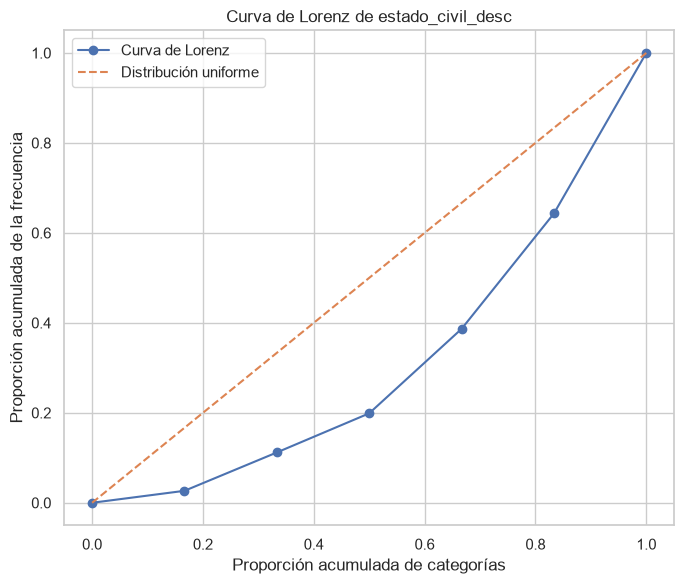

In [8]:
from src.statistics.concentracion import curva_lorenz
proporcion_categorias, proporcion_acumulada = curva_lorenz(
    frecuencias
)

plt.figure(figsize=(7, 6))

plt.plot(
    proporcion_categorias,
    proporcion_acumulada,
    marker="o",
    label="Curva de Lorenz"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Distribución uniforme"
)

plt.xlabel("Proporción acumulada de categorías")
plt.ylabel("Proporción acumulada de la frecuencia")
plt.title("Curva de Lorenz de estado_civil_desc")

plt.legend()
plt.tight_layout()
plt.show()


## 6. Interpretación y limitaciones

La entropía de Shannon indica que las 6 categorías de estado civil son bastante heterogéneas, porque la distribución, como se observa, no es uniforme en lo absoluto, la mayoría está distribuida en `casada', `soltera´ y `unión libre´, lo cual, también tiene un impacto en Gini.
